Shapefile columns:
['CFSAUID', 'PRUID', 'PRNAME', 'geometry']
ROI bounds in map CRS:
7057002.720368397 806406.6780317933 7113191.1305652745 854151.1294732154


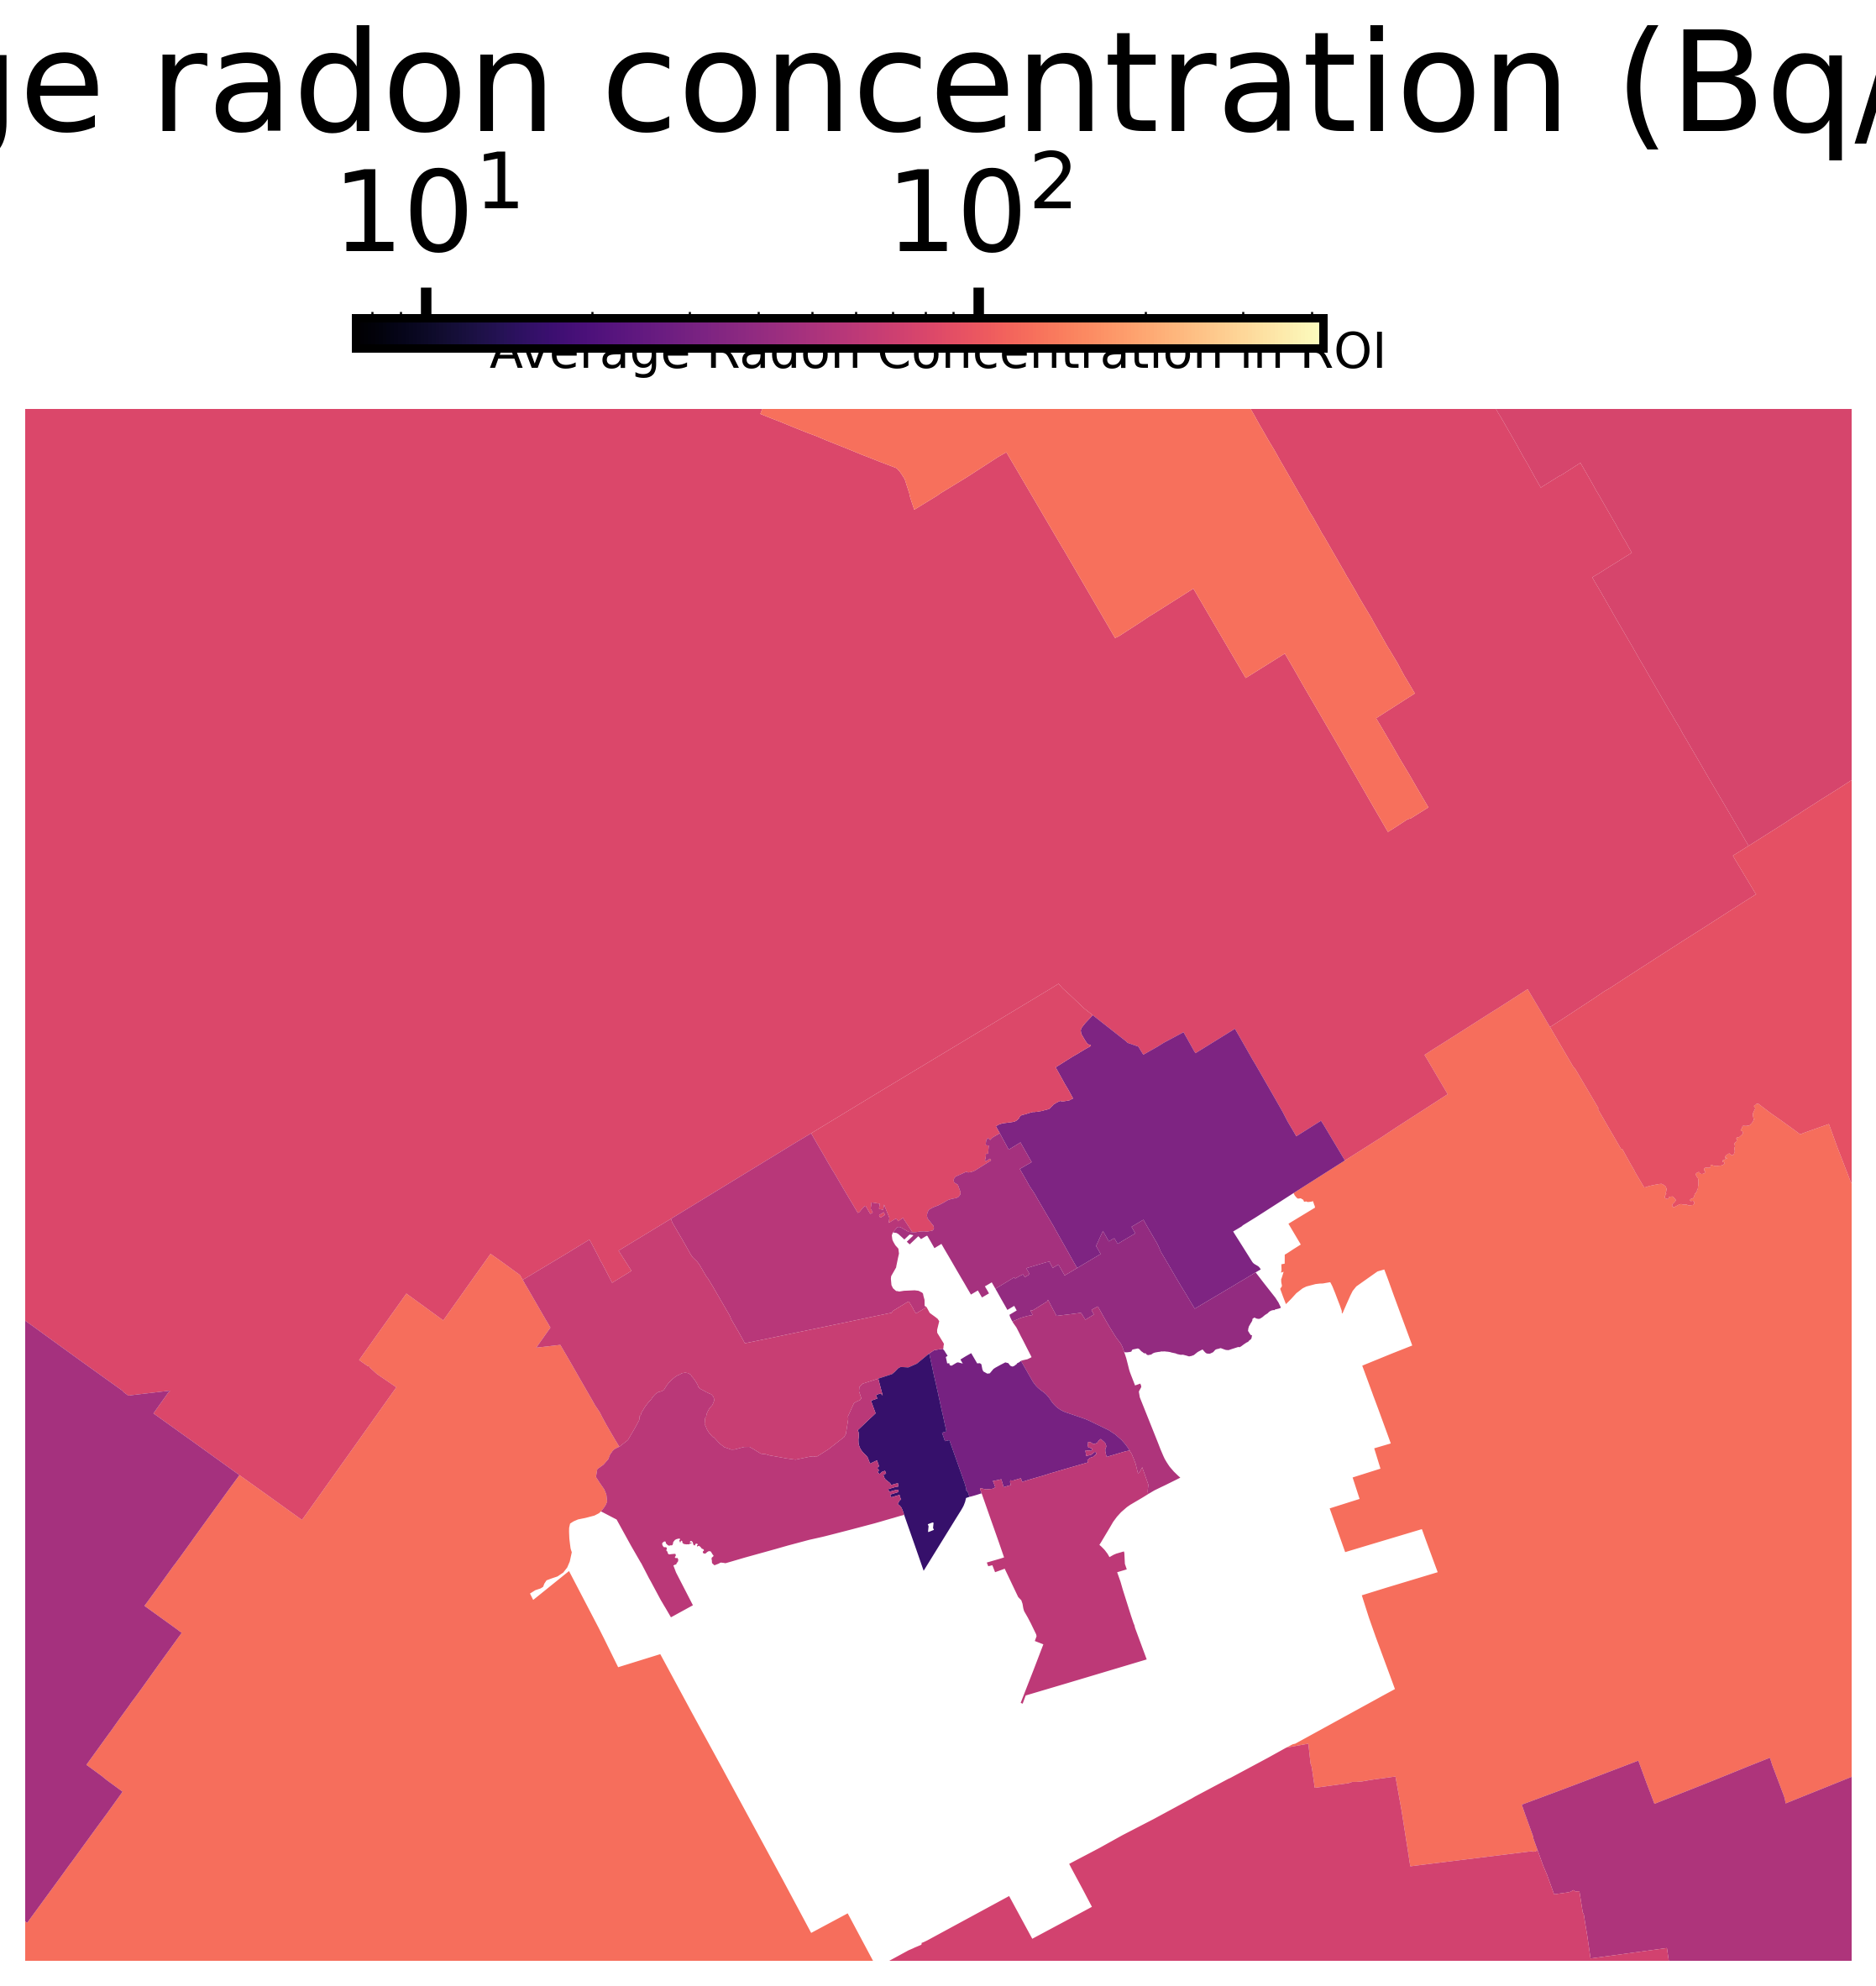

In [1]:
from pathlib import Path
import sys
import os

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import MAIN_DATASET, FIGURES_DIR
from config.paths import FSA_BOUNDARY_SHAPEFILE


# ------------------------------------------------------------
# Load radon data
# ------------------------------------------------------------
data = pd.read_csv(MAIN_DATASET)

mean_concentration_by_fsa = (
    data.groupby("FSA", as_index=False)
    .agg(
        concentration_mean=("concentration", "mean"),
        provinceterritory=("provinceterritory", "first")
    )
)

mean_concentration_by_fsa["FSA"] = mean_concentration_by_fsa["FSA"].astype(str)


# ------------------------------------------------------------
# Load FSA polygons
# ------------------------------------------------------------
fsa_boundaries = gpd.read_file(FSA_BOUNDARY_SHAPEFILE)

print("Shapefile columns:")
print(fsa_boundaries.columns.tolist())


# ------------------------------------------------------------
# Find the FSA ID column in the shapefile
# ------------------------------------------------------------
possible_fsa_columns = [
    "FSA",
    "CFSAUID",
    "CFSAUID1",
    "POSTALCODE",
    "FSA_CODE"
]

shapefile_fsa_column = None
for column_name in possible_fsa_columns:
    if column_name in fsa_boundaries.columns:
        shapefile_fsa_column = column_name
        break

if shapefile_fsa_column is None:
    raise ValueError(
        "Could not find the FSA identifier column in the shapefile. "
        "Check the printed columns and set shapefile_fsa_column manually."
    )

fsa_boundaries[shapefile_fsa_column] = fsa_boundaries[shapefile_fsa_column].astype(str)


# ------------------------------------------------------------
# Merge mean concentration onto polygons
# ------------------------------------------------------------
fsa_map = fsa_boundaries.merge(
    mean_concentration_by_fsa,
    left_on=shapefile_fsa_column,
    right_on="FSA",
    how="left"
)

if fsa_map.crs is None:
    raise ValueError("The shapefile CRS is missing.")

fsa_map = fsa_map.to_crs("EPSG:3347")


# ------------------------------------------------------------
# Color scaling
# ------------------------------------------------------------
positive_values = fsa_map.loc[
    fsa_map["concentration_mean"].notna() &
    (fsa_map["concentration_mean"] > 0),
    "concentration_mean"
]

if len(positive_values) == 0:
    raise ValueError("No positive concentration values found.")

vmin = max(positive_values.min(), 1)
vmax = positive_values.quantile(0.99)

norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = "magma"


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

fig.patch.set_alpha(0)
ax.set_facecolor("none")

fsa_map.plot(
    column="concentration_mean",
    cmap=cmap,
    norm=norm,
    linewidth=0.05,
    edgecolor="none",
    legend=False,
    missing_kwds={
        "color": "none",
        "edgecolor": "none"
    },
    ax=ax
)

ax.set_title(
    "Average Radon Concentration in ROI",
    fontsize=14,
    pad=12
)
ax.set_axis_off()


# ------------------------------------------------------------
# Horizontal legend near the top
# ------------------------------------------------------------
cax = fig.add_axes([0.32, 0.91, 0.32, 0.015])
cax.set_facecolor("none")

scalar_mappable = ScalarMappable(norm=norm, cmap=cmap)
scalar_mappable.set_array([])

cbar = fig.colorbar(
    scalar_mappable,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(
    "Average radon concentration (Bq/m³)",
    fontsize=40,
    labelpad=10
)

cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")

cbar.ax.tick_params(
    labelsize=32,
    width=3.0,
    length=9,
    labeltop=True,
    labelbottom=False,
    top=True,
    bottom=False
)

cbar.outline.set_linewidth(2.4)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(2.4)

cbar.ax.set_facecolor("none")


# ------------------------------------------------------------
# ROI: London, Ontario area
# Coordinates here are lon/lat in EPSG:4326
# ------------------------------------------------------------
roi_bbox_lonlat = box(-81.55, 42.85, -80.95, 43.20)

roi_bbox = gpd.GeoSeries(
    [roi_bbox_lonlat],
    crs="EPSG:4326"
).to_crs(fsa_map.crs)

xmin, ymin, xmax, ymax = roi_bbox.total_bounds

print("ROI bounds in map CRS:")
print(xmin, ymin, xmax, ymax)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------
# plt.savefig(
#     "average_radon_roi_map.png",
#     dpi=300,
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()

Shapefile columns:
['CFSAUID', 'PRUID', 'PRNAME', 'geometry']
['N0J', 'N0L', 'N0M', 'N4X', 'N5C', 'N5P', 'N5V', 'N5W', 'N5X', 'N5Y', 'N5Z', 'N6A', 'N6B', 'N6C', 'N6E', 'N6G', 'N6H', 'N6J', 'N6K', 'N6L', 'N6M', 'N6N', 'N6P', 'N7G']
Number of FSA polygons intersecting ROI: 24
Highlighted FSA: N6E


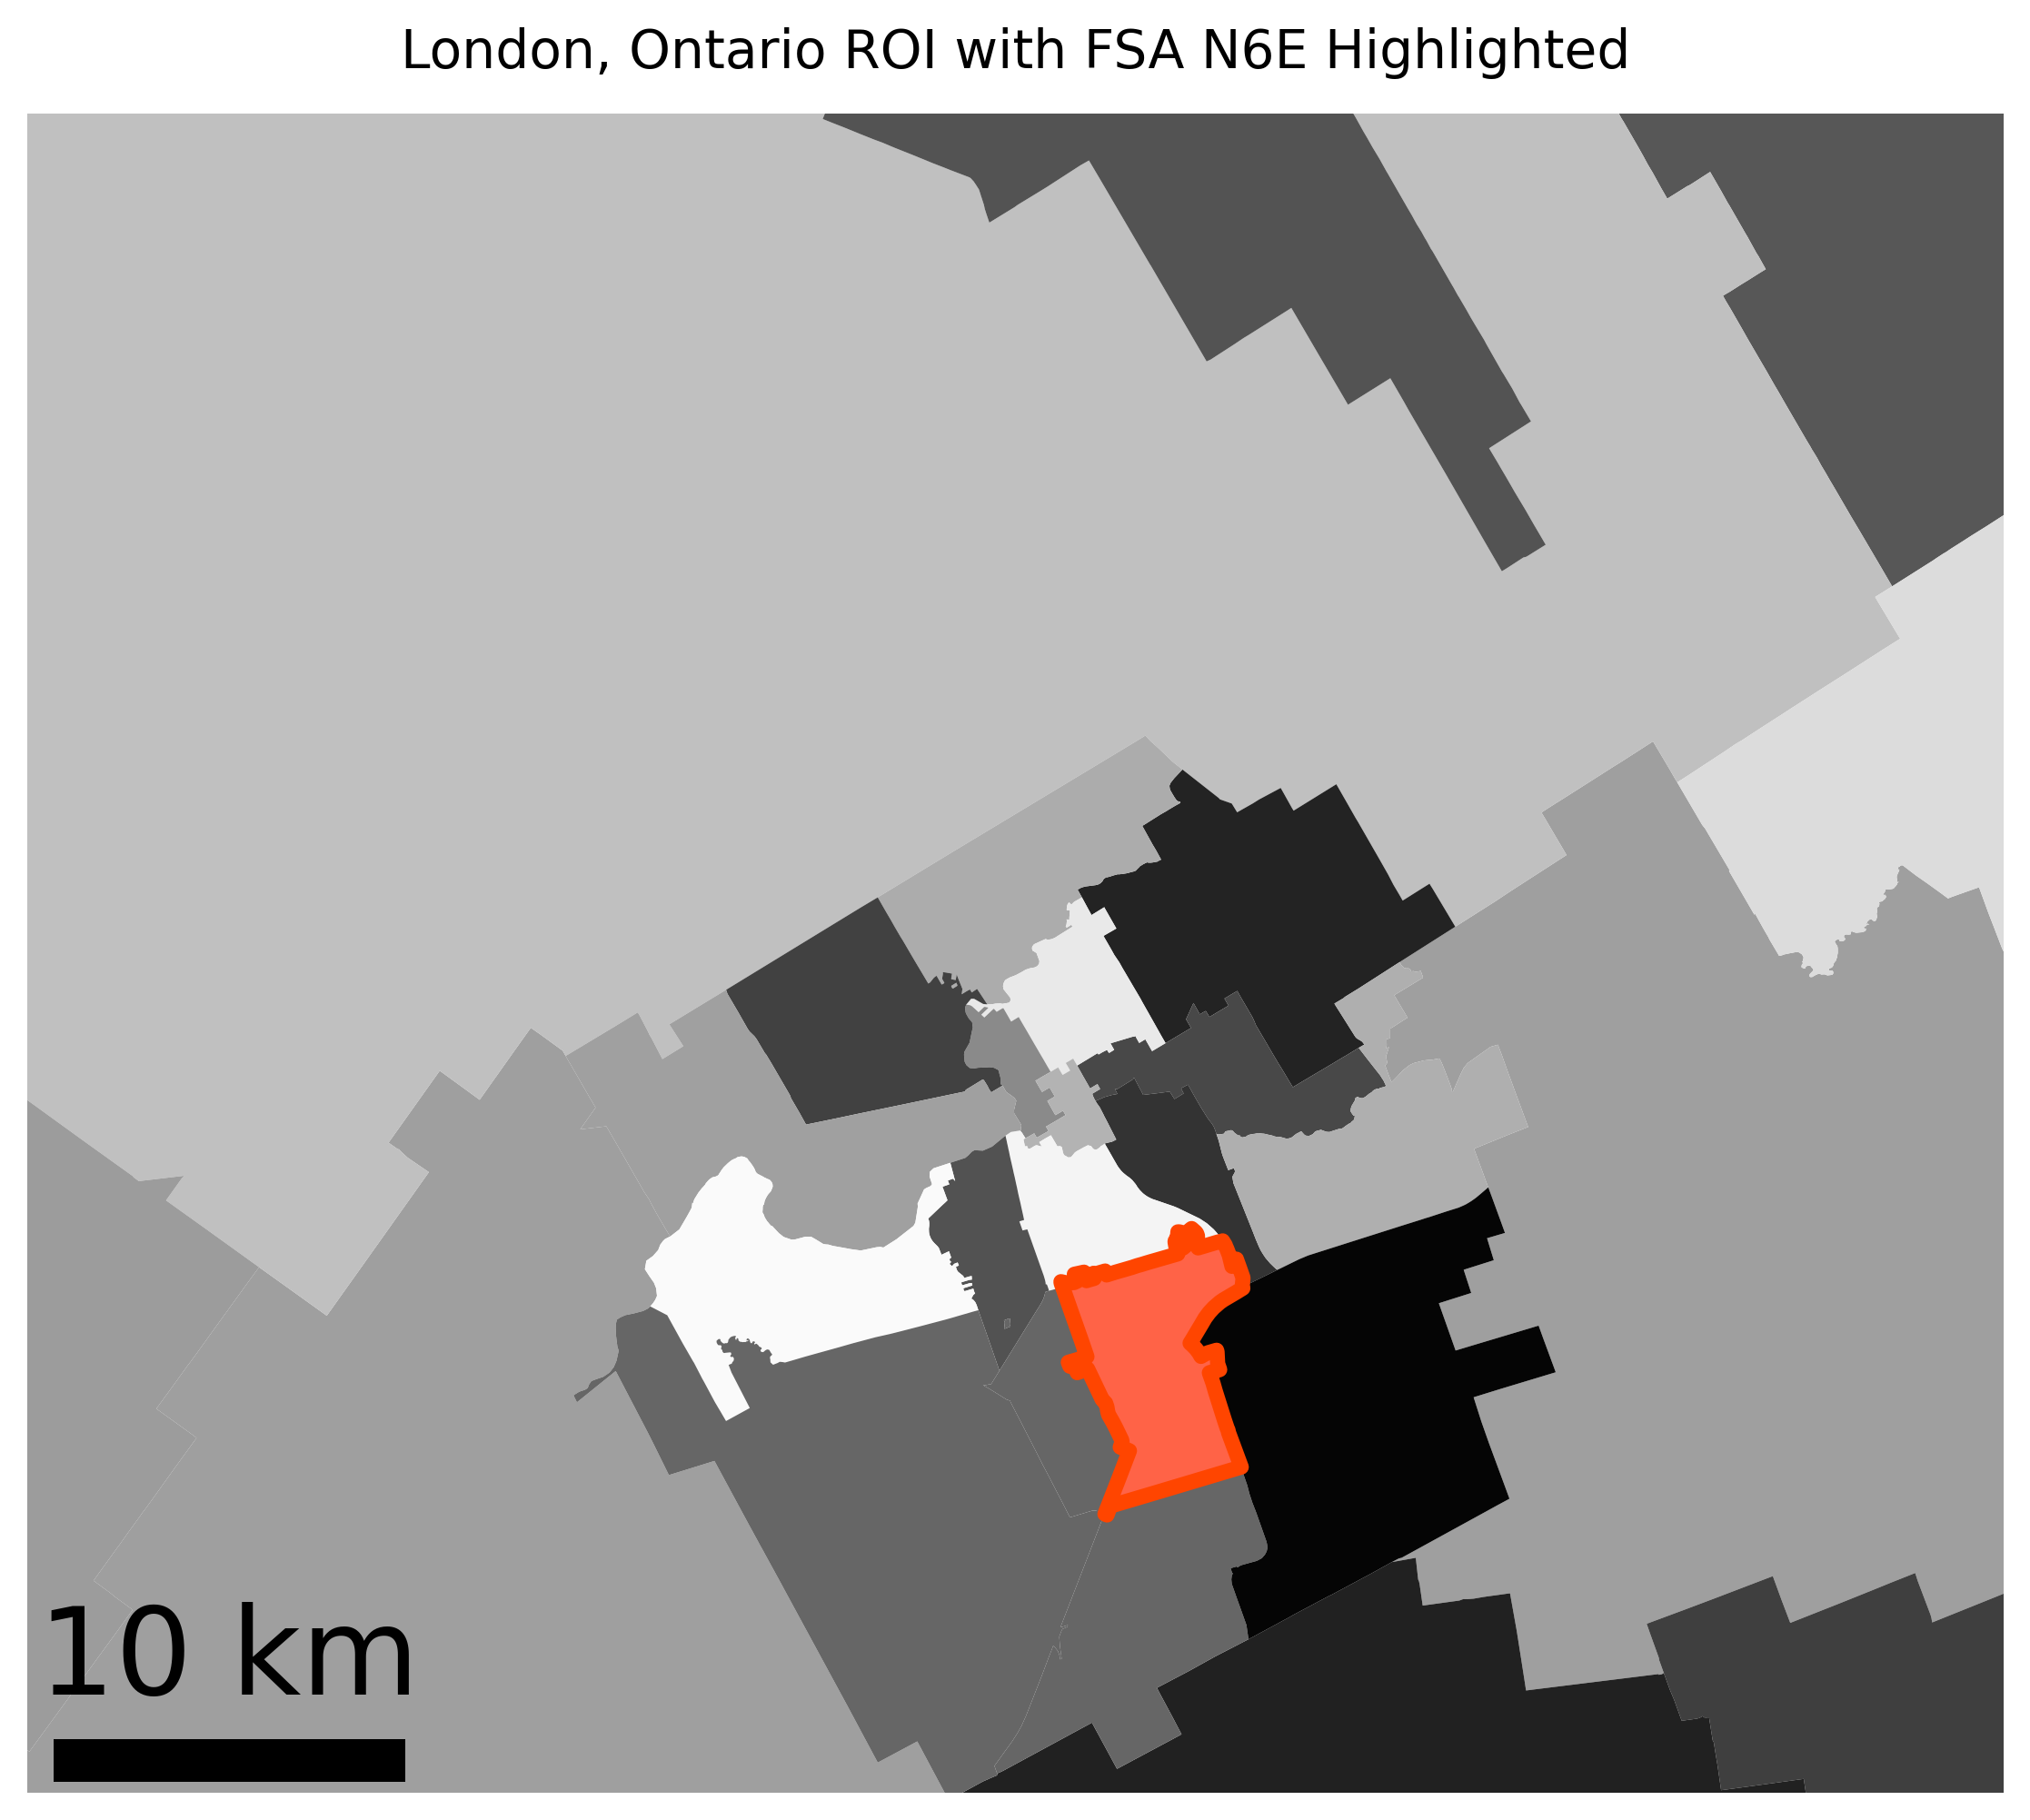

In [2]:
from pathlib import Path
import sys

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

from shapely.geometry import box


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import FSA_BOUNDARY_SHAPEFILE


# ------------------------------------------------------------
# Load FSA polygons
# ------------------------------------------------------------
fsa_boundaries = gpd.read_file(FSA_BOUNDARY_SHAPEFILE)

print("Shapefile columns:")
print(fsa_boundaries.columns.tolist())


# ------------------------------------------------------------
# Find the FSA identifier column
# ------------------------------------------------------------
possible_fsa_columns = [
    "FSA",
    "CFSAUID",
    "CFSAUID1",
    "POSTALCODE",
    "FSA_CODE"
]

shapefile_fsa_column = None
for column_name in possible_fsa_columns:
    if column_name in fsa_boundaries.columns:
        shapefile_fsa_column = column_name
        break

if shapefile_fsa_column is None:
    raise ValueError(
        "Could not find the FSA identifier column in the shapefile. "
        "Check the printed columns and set shapefile_fsa_column manually."
    )

fsa_boundaries[shapefile_fsa_column] = (
    fsa_boundaries[shapefile_fsa_column]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# Reproject to a projected CRS for Canada
# ------------------------------------------------------------
if fsa_boundaries.crs is None:
    raise ValueError("The shapefile CRS is missing.")

fsa_map = fsa_boundaries.to_crs("EPSG:3347").copy()


# ------------------------------------------------------------
# Assign random grayscale values
# One random value per FSA polygon
# ------------------------------------------------------------
rng = np.random.default_rng(42)
#fsa_map["random_value"] = rng.random(len(fsa_map))
fsa_map["random_value"] = 0.3 + 0.4 * rng.random(len(fsa_map))

# ------------------------------------------------------------
# Define ROI around London, Ontario
# These coordinates are lon/lat in EPSG:4326
# ------------------------------------------------------------
roi_bbox_lonlat = box(-81.55, 42.85, -80.95, 43.20)

roi_bbox = gpd.GeoSeries(
    [roi_bbox_lonlat],
    crs="EPSG:4326"
).to_crs(fsa_map.crs)

xmin, ymin, xmax, ymax = roi_bbox.total_bounds


# ------------------------------------------------------------
# Find FSA polygons intersecting the ROI
# ------------------------------------------------------------
fsa_in_roi = fsa_map[fsa_map.intersects(roi_bbox.iloc[0])].copy()
print(sorted(fsa_in_roi[shapefile_fsa_column].unique()))

print("Number of FSA polygons intersecting ROI:", len(fsa_in_roi))

if len(fsa_in_roi) == 0:
    raise ValueError("No FSA polygons found in the ROI.")


# ------------------------------------------------------------
# Pick one FSA within the ROI to highlight
# Here: choose the first one after sorting by FSA code
# ------------------------------------------------------------
fsa_in_roi = fsa_in_roi.sort_values(by=shapefile_fsa_column)
#highlight_fsa_code = fsa_in_roi.iloc[0][shapefile_fsa_column]
highlight_fsa_code = "N6E"

print("Highlighted FSA:", highlight_fsa_code)

highlight_fsa = fsa_map[
    fsa_map[shapefile_fsa_column] == highlight_fsa_code
].copy()


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Plot all FSAs in grayscale using random values
fsa_map.plot(
    column="random_value",
    cmap="gray",
    linewidth=0,
    edgecolor="none",
    legend=False,
    ax=ax
)

# Overlay the highlighted FSA in dark cyan
highlight_fsa.plot(
    ax=ax,
    color="tomato",
    edgecolor="orangered",
    linewidth=4
)

# Zoom to ROI
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(
    f"London, Ontario ROI with FSA {highlight_fsa_code} Highlighted",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# Scalebar...

# outline_scalebar = ScaleBar(
#     dx=1,
#     units="m",
#     dimension="si-length",
#     fixed_value=10*1.01,
#     fixed_units="km",
#     location="lower center",
#     scale_loc="top",
#     box_alpha=0.0,
#     color="white",
#     font_properties={"size": 1},
#     width_fraction=0.01 * 1.1
# )
#ax.add_artist(outline_scalebar)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",
    fixed_value=10,
    fixed_units="km",
    location="lower left",
    scale_loc="top",
    box_alpha=0.0,
    color="black",
    font_properties={"size": 32},
    width_fraction=0.025
)


ax.add_artist(scalebar)




########################################################
plt.savefig(
    os.path.join(FIGURES_DIR, "london_roi_random_fsa_grayscale_with_highlight.png"),
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()